## Chatbot and RAG Evaluation 

Retrieval Augmented Generation (RAG) is a technique that enhances Large Language Models (LLMs) by providing them with relevant external knowledge. It has become one of the most widely used approaches for buidling LLM applications. 

This tutorial will show you how to evaluate your RAG applications using LangSmith. You'll learn: 
1. How to create test datasets 
2. How to run your RAG application on those datasets 
3. How to measure your application's perfomance using different evaluation metrics 


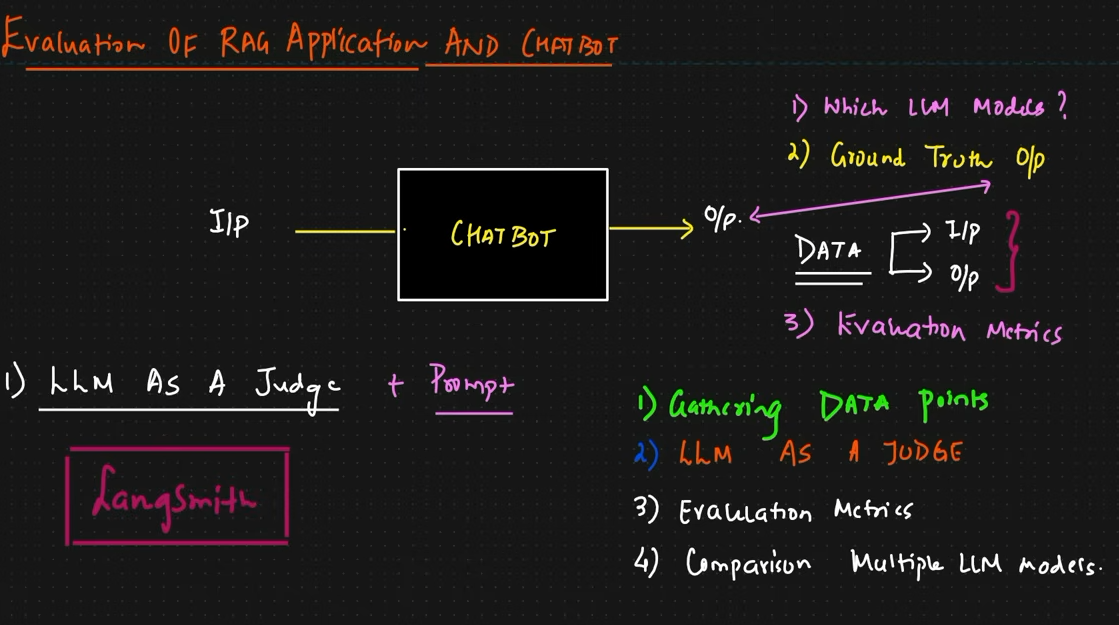

#### Overview 

A typical RAG evaluation workflow consists of three main steps: 
1. Creating a dataset with questions and their expected answers 
2. Running your RAG application on those questions 
3. Using evaluators to measure how well your paplication performed, looking at factors like: 

    - Answer relevance 
    - Answer accuracy 
    - Retrieval quality 

For this tutorial, we'll create and evaluate a bot that answers questions aboiut a few of Lilian Weng's insightful blog posts 

### Chatbot Evaluation 

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["LANGSMITH_API_KEY"]=os.getenv("LANGCHAIN_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["LANGSMITH_TRACING"]="true"

In [2]:
from langsmith import Client

client = Client()

# Define dataset: these are your test cases
# dataset_name = "Chatbots Evaluation"
# dataset = client.create_dataset(dataset_name)
# client.create_examples(
#     dataset_id=dataset.id,
#     examples=[
#         {
#             "inputs": {"question": "What is LangChain?"},
#             "outputs": {"answer": "A framework for building LLM applications"},
#         },
#         {
#             "inputs": {"question": "What is LangSmith?"},
#             "outputs": {"answer": "A platform for observing and evaluating LLM applications"},
#         },
#         {
#             "inputs": {"question": "What is OpenAI?"},
#             "outputs": {"answer": "A company that creates Large Language Models"},
#         },
#         {
#             "inputs": {"question": "What is Google?"},
#             "outputs": {"answer": "A technology company known for search"},
#         },
#         {
#             "inputs": {"question": "What is Mistral?"},
#             "outputs": {"answer": "A company that creates Large Language Models"},
#         }
#     ]
# )

#### Define Metrics (LLM as a Judge)

In [54]:
from langsmith import wrappers 
from langchain_groq import ChatGroq

eval_instructions = "You are an expert professor sepcialized in grading students' answers to questions."

def correctness(inputs:dict, outputs: dict, reference_outputs: dict) -> bool: 
    user_content = f"""You are grading the following questions: 
    {inputs['question']}
    Here is the real answer: 
    {reference_outputs['answer']}
    You are grading the following predicted answer: 
    {outputs['response']}
    Respond with CORRECT or INCORRECT: 
    Grade: 
    """

    llm  = ChatGroq(
        model = "openai/gpt-oss-20b", 
        temperature=0)
    response = llm.invoke( [
                {"role": "system", "content": eval_instructions}, 
                {"role": "user", "content": user_content}
            ])

    return response.content.strip() == 'CORRECT'

In [55]:
## Concisions - checks whether the actual output is less than 2X the lenght of the expected result 

def concision(outputs: dict, reference_outputs: dict) -> bool: 
    return int(len(outputs["response"]) < 2 * len(reference_outputs["answer"]))

#### Run Evaluations 

In [56]:
default_intstructions = "Repond to the users questions in a short, concise manner (one short sentence)"
def my_app(question: str, model: str = "openai/gpt-oss-20b", instructions: str = default_intstructions):
    llm = ChatGroq(model=model, temperature=0)
    response = llm.invoke([
        {"role": "system", "content": instructions},
        {"role": "user", "content": question}
    ])
    return response.content

In [57]:
### Call my_app for every datapoints 
def ls_target(inputs: str) -> dict: 
    return {"response": my_app(inputs["question"])}

In [58]:
## Run our evaluation
experiment_results=client.evaluate(
    ls_target, ## Your AI system
    data=dataset_name,
    evaluators=[correctness,concision],
    experiment_prefix="openai/gpt-oss-20b"
)

View the evaluation results for experiment: 'openai/gpt-oss-20b-5b45fa73' at:
https://smith.langchain.com/o/8ee69959-5811-4101-9628-f1aaeaf404f4/datasets/d8618cf5-cd28-44c7-be41-b8f979bb612e/compare?selectedSessions=cfa5c0ed-65bd-401a-9be4-059c0212ef50




5it [00:07,  1.44s/it]


In [ ]:
### Col my app for every datapoints 
def ls_target(inputs: str) -> dict: 
    return {"response": my_app(inputs['question'], model = "openai/gpt-oss-120b-mini")}

In [ ]:
## Run our evaluation
experiment_results=client.evaluate(
    ls_target, ## Your AI system
    data=dataset_name,
    evaluators=[correctness,concision],
    experiment_prefix="openai/gpt-oss-120b-mini"
)

View the evaluation results for experiment: 'groq/compound-mini-4a150092' at:
https://smith.langchain.com/o/8ee69959-5811-4101-9628-f1aaeaf404f4/datasets/d8618cf5-cd28-44c7-be41-b8f979bb612e/compare?selectedSessions=c8b17af1-c3c6-41b0-b72f-5209cbb6356c




5it [00:23,  4.68s/it]


### Evaluation for RAG 

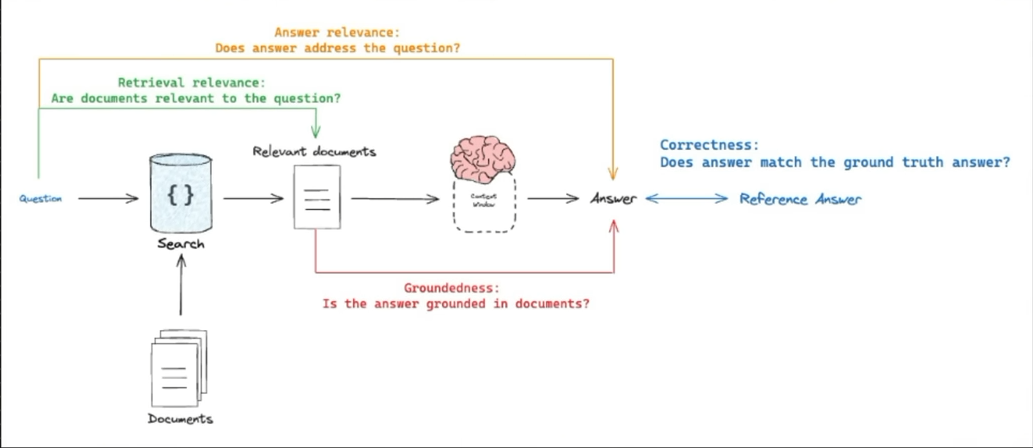

#### RAG Evaluation Metrics

* **Retrieval Relevance**: Measures whether the retrieved document chunks are relevant and sufficient to answer the question (`Question` $\rightarrow$ `Context`).
* **Groundedness**: Measures whether the generated answer relies strictly on the retrieved context without introducing unmentioned facts or hallucinations (`Context` $\rightarrow$ `Answer`).
* **Answer Relevance**: Measures how directly and completely the generated output addresses the original query (`Question` $\rightarrow$ `Answer`).
* **Correctness**: Measures how accurately the final generated output matches the human-verified reference answer (`Answer` $\leftrightarrow$ `Ground Truth`).

In [3]:
# RAG 
from langchain_community.document_loaders import WebBaseLoader
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

# List of urls to load documents from 
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]

# Load documents from the URLs 
docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]


# Initialize a text splitter with sepcified chunk size and overlap 
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size = 250, chunk_overlap = 0
)

# split the documents into chunks 
doc_splits = text_splitter.split_documents(docs_list) 

# Initialize embedding model 
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

# add the document chunks to the vector using sentence transformer 
vectorStore = InMemoryVectorStore.from_documents(
    documents = doc_splits,
    embedding=embeddings
)


# With langchain we can easily turn any vector store into a retreival commponent
retriever = vectorStore.as_retriever(k=6)

C:\Users\manas\AppData\Local\Temp\ipykernel_29848\2742996582.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WebBaseLoader
c:\Users\manas\Documents\development\langgraph-learning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9243.30it/s]


In [4]:
retriever.invoke("what is agent")

[Document(id='b4442dea-b17b-4c68-8668-7067ffdc0fa0', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, 

In [5]:
from langchain.chat_models import init_chat_model 
llm = init_chat_model("groq:openai/gpt-oss-120b")
llm 

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.0', 'langchain': '1.3.15'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000233BDA43620>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000233F79D41A0>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [6]:
from langsmith import traceable

# Add Decorator 
@traceable
def rag_bot(question: str) -> dict: 
    ## Relevant context 
    docs = retriever.invoke(question)
    docs_string = " ".join(doc.page_content for doc in docs)

    instructions = f"""You are a helpful assistant who is good at analyzing source information and answering questions.       Use the following source documents to answer the user's questions.       If you don't know the answer, just say that you don't know.       Use three sentences maximum and keep the answer concise.

Documents:
{docs_string}"""

    ## LLM invoke 
    ai_msg = llm.invoke([
        {"role": "system", "content": instructions}, 
        {"role": "user", "content": question}
    ])

    return {"answer": ai_msg.content, "documents": docs}

In [7]:
rag_bot("what is ai agents?")

{'answer': 'AI agents are autonomous systems whose core “brain” is a large language model (LLM) that can interpret prompts, generate actions, and make decisions. They combine planning (subgoal decomposition and self‑reflection), memory (long‑term experience storage and retrieval), and tool use to interact with environments and other agents. This architecture lets them solve complex tasks, learn from past actions, and behave in a human‑like, context‑aware manner.',
 'documents': [Document(id='58c99f26-9e20-442e-ac37-5e752504ebc2', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a po

### Dataset 

In [16]:
from langsmith import Client 

client = Client()

# Define the exampels for the dataset 
examples = [
    {
        "inputs": {"question": "How does the ReAct agent use self-reflection? "},
        "outputs": {"answer": "ReAct integrates reasoning and acting, performing actions - such tools like Wikipedia search API - and then observing / reasoning about the tool outputs."},
    },
    {
        "inputs": {"question": "What are the types of biases that can arise with few-shot prompting?"},
        "outputs": {"answer": "The biases that can arise with few-shot prompting include (1) Majority label bias, (2) Recency bias, and (3) Common token bias."},
    },
    {
        "inputs": {"question": "What are five types of adversarial attacks?"},
        "outputs": {"answer": "Five types of adversarial attacks are (1) Token manipulation, (2) Gradient based attack, (3) Jailbreak prompting, (4) Human red-teaming, (5) Model red-teaming."},
    }
]


# Create the dataset and exmaple in Langsmith 
dataset_name = "RAG Test Evaluation"
dataset = client.create_dataset(dataset_name=dataset_name)
client.create_examples(
    dataset_id=dataset.id, 
    examples=examples
)

{'example_ids': ['5e47a47d-f0d2-48ce-bfdf-159d57ce5627',
  'a17cc562-88b9-4a22-9077-33f23b4e6ec0',
  'cafa63b2-2be5-4deb-99ea-a668045593ec'],
 'count': 3,
 'as_of': '2026-08-30T04:31:04.51612188Z'}

#### Evaluators or Metrics 



1. Correctness: Response vs Reference answer 

- Goal: Measure "how similiar/correct is the RAG chain answer, relative to a ground-truth answer"
- Mode: Requires a ground truth (reference) answer supplied through a dataset 
- Evaluator: use LLM as judge to assess answer correctness 

In [9]:
from typing_extensions import Annotated, TypedDict
from langchain_groq import ChatGroq

## Correctness Output Schema 

#Grade output schema 
class CorrectnessGrade(TypedDict): 
    # Note that the order in the fields are defined is the order in which the model will generate them. 
    # It is useful to put expmlanations before responses because if forces the model to think through 
    # its' final response before generating it: 
    explantion: Annotated[str, ..., "Explain your reasoning for the score"]
    correct: Annotated[str, ..., "True if the answer is correct, False otherwise"]


## correctness prompt 

correctness_instructions = """You are a teacher grading a quiz. 

You will be given a QUESTION, the GROUND TRUTH (correct) ANSWER, and the STUDENT ANSWER. 

Here is the grade criteria to follow:
(1) Grade the student answers based ONLY on their factual accuracy relative to the ground truth answer. 
(2) Ensure that the student answer does not contain any conflicting statements.
(3) It is OK if the student answer contains more information than the ground truth answer, as long as it is factually accurate relative to the  ground truth answer.

Correctness:
A correctness value of True means that the student's answer meets all of the criteria.
A correctness value of False means that the student's answer does not meet all of the criteria.

Explain your reasoning in a step-by-step manner to ensure your reasoning and conclusion are correct. 

Avoid simply stating the correct answer at the outset."""


grader_llm = ChatGroq(model = "openai/gpt-oss-120b", temperature = 0).with_structured_output(CorrectnessGrade, method = "json_schema", strict=True)


## evaluator 
def correctness(inputs: dict, outputs: dict, reference_outputs: dict) -> bool: 
    """An evaluator for RAG answer accuracy"""
    answers = f"""\
QUESTION: {inputs['question']}
GROUND TRUTH ANSWER: {reference_outputs['answer']}
STUDENT ANSWER: {outputs['answer']}"""

    # Run evaluator
    grade = grader_llm.invoke([ 
        {"role": "system", "content": correctness_instructions}, 
        {"role": "user", "content": answers}
    ])
    return grade["correct"]

#### Relevance: Response vs Input 


The flow is similiar to above, but we simply look at the inputs and outputs without needing the reference_outputs. Without a reference answer we can't grade accuracy, but can still grade relevance --- as in, did the model address the user's question or not 

In [10]:
## Grade output schema 
class RelevanceGrade(TypedDict): 
    explanation: Annotated[str, ..., "Explain your reasoning for the score"]
    relevant: Annotated[bool, ..., "Provide the score on whether the answer addresses the question"]


# Grade prompt
relevance_instructions="""You are a teacher grading a quiz. 

You will be given a QUESTION and a STUDENT ANSWER. 

Here is the grade criteria to follow:
(1) Ensure the STUDENT ANSWER is concise and relevant to the QUESTION
(2) Ensure the STUDENT ANSWER helps to answer the QUESTION

Relevance:
A relevance value of True means that the student's answer meets all of the criteria.
A relevance value of False means that the student's answer does not meet all of the criteria.

Explain your reasoning in a step-by-step manner to ensure your reasoning and conclusion are correct. 

Avoid simply stating the correct answer at the outset."""

# Grader LLM 
relevance_llm = ChatGroq(model = "openai/gpt-oss-120b", temperature =0).with_structured_output(RelevanceGrade, method = "json_schema", strict = True)

# Evaluator 
def relevance(inputs: dict, outputs: dict) -> bool: 
    """A simple evaluator for RAG answer helpfulness"""
    answer = f"QUESTION: {inputs['question']}\nSTUDENT ANSWER: {outputs['answer']}"
    grade = relevance_llm.invoke([
        {"role": "system", "content": relevance_instructions}, 
        {"role": "user", "content": answer}
    ])
    return grade["relevant"]

#### Groundedness: Response vs retrieved docs 


Another useful way to evaluate responses without needing reference answers is to check if the response is justified by (or "grounded in ") the retrieved documents. It is basically the opposite of hallucination where you have the reponse based on the answer that you have retrieved 

In [11]:
# Grade output schema 
class GroundedGrade(TypedDict):
    explanation: Annotated[str, ..., "Explain your reasoning for the score"]
    grounded: Annotated[bool, ..., "Provide the score on if the answer hallucinates from the documents"]

# Grade prompt
grounded_instructions = """You are a teacher grading a quiz. 

You will be given FACTS and a STUDENT ANSWER. 

Here is the grade criteria to follow:
(1) Ensure the STUDENT ANSWER is grounded in the FACTS. 
(2) Ensure the STUDENT ANSWER does not contain "hallucinated" information outside the scope of the FACTS.

Grounded:
A grounded value of True means that the student's answer meets all of the criteria.
A grounded value of False means that the student's answer does not meet all of the criteria.

Explain your reasoning in a step-by-step manner to ensure your reasoning and conclusion are correct. 

Avoid simply stating the correct answer at the outset."""


# Grader LLM 
grounded_llm = ChatGroq(model="openai/gpt-oss-120b", temperature=0).with_structured_output(GroundedGrade, method="json_schema", strict=True)

# Evaluator
def groundedness(inputs: dict, outputs: dict) -> bool:
    """A simple evaluator for RAG answer groundedness."""
    doc_string = "\n\n".join(doc.page_content for doc in outputs["documents"])
    answer = f"FACTS: {doc_string}\nSTUDENT ANSWER: {outputs['answer']}"
    grade = grounded_llm.invoke([{"role": "system", "content": grounded_instructions}, {"role": "user", "content": answer}])
    return grade["grounded"]

#### Retrieval Relevance : Retrieved docs vs Input 

In [12]:
# Grade output schema
class RetrievalRelevanceGrade(TypedDict):
    explanation: Annotated[str, ..., "Explain your reasoning for the score"]
    relevant: Annotated[bool, ..., "True if the retrieved documents are relevant to the question, False otherwise"]

# Grade prompt
retrieval_relevance_instructions = """You are a teacher grading a quiz. 

You will be given a QUESTION and a set of FACTS provided by the student. 

Here is the grade criteria to follow:
(1) You goal is to identify FACTS that are completely unrelated to the QUESTION
(2) If the facts contain ANY keywords or semantic meaning related to the question, consider them relevant
(3) It is OK if the facts have SOME information that is unrelated to the question as long as (2) is met

Relevance:
A relevance value of True means that the FACTS contain ANY keywords or semantic meaning related to the QUESTION and are therefore relevant.
A relevance value of False means that the FACTS are completely unrelated to the QUESTION.

Explain your reasoning in a step-by-step manner to ensure your reasoning and conclusion are correct. 

Avoid simply stating the correct answer at the outset."""

# Grader LLM
retrieval_relevance_llm = ChatGroq(model="openai/gpt-oss-120b", temperature=0).with_structured_output(RetrievalRelevanceGrade, method="json_schema", strict=True)

def retrieval_relevance(inputs: dict, outputs: dict) -> bool:
    """An evaluator for document relevance"""
    doc_string = "\n\n".join(doc.page_content for doc in outputs["documents"])
    answer = f"FACTS: {doc_string}\nQUESTION: {inputs['question']}"

    # Run evaluator
    grade = retrieval_relevance_llm.invoke([
        {"role": "system", "content": retrieval_relevance_instructions}, 
        {"role": "user", "content": answer}
    ])
    return grade["relevant"]

#### Run the Evaluation 

In [17]:


def target(inputs: dict) -> dict: 
    return rag_bot(inputs["question"])

experiment_results = client.evaluate(
    target, 
    data = dataset_name, 
    evaluators=[correctness, groundedness, relevance, retrieval_relevance], 
    experiment_prefix = "rag-doc-relevance", 
    metadata = {"version": "LCEL context, groq-compound-mini"}
)

View the evaluation results for experiment: 'rag-doc-relevance-b253de5f' at:
https://smith.langchain.com/o/8ee69959-5811-4101-9628-f1aaeaf404f4/datasets/ae9a03b0-6265-44c0-b8dc-1e6b57f8af9d/compare?selectedSessions=7690b879-1ee4-4ea1-988b-350eb817f5a8




3it [01:13, 24.55s/it]
